In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

### Interpretation
This cell loads the core Python libraries used throughout the project. Pandas handles data loading and manipulation, NumPy supports numerical operations, Matplotlib and Seaborn are used for visualizations, and `train_test_split` will later be used to divide the data into training and testing sets.


In [ ]:
import pandas as pd
df = pd.read_csv("/content/house_price_prediction_dataset_10000.csv")
df.head()

,property_id,area_sqft,bedrooms,bathrooms,property_age,location,location_score,distance_city_km,crime_rate_index,property_type,furnishing_status,parking_spaces,floor_number,total_floors,has_garage,has_pool,house_price_inr
0,1,1310.0,4,3,4,Bangalore,5.97,0.81,54.97,Independent House,Unfurnished,2,9,26,No,No,11330000
1,2,4222.0,5,3,40,Delhi,8.07,6.70,23.57,Independent House,Fully Furnished,2,18,18,No,No,41875000
2,3,3542.0,3,2,7,Kolkata,5.53,10.11,76.20,Apartment,Semi-Furnished,1,28,39,No,No,12979000
3,4,916.0,2,2,16,Surat,3.82,28.03,84.95,Apartment,Unfurnished,2,16,18,No,No,2298000
4,5,4876.0,3,3,17,Pune,8.03,24.55,48.70,Villa,Semi-Furnished,3,16,18,No,No,44137000


### Interpretation
The dataset is loaded into a Pandas DataFrame called `df`, and `head()` displays the first five rows. This gives an initial look at the available columns, such as area, bedrooms, bathrooms, location, and price, which will be used to build the prediction model.


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   property_id        10000 non-null  int64  
 1   area_sqft          9980 non-null   float64
 2   bedrooms           10000 non-null  int64  
 3   bathrooms          10000 non-null  int64  
 4   property_age       10000 non-null  int64  
 5   location           9985 non-null   object 
 6   location_score     9985 non-null   float64
 7   distance_city_km   10000 non-null  float64
 8   crime_rate_index   9990 non-null   float64
 9   property_type      9988 non-null   object 
 10  furnishing_status  9990 non-null   object 
 11  parking_spaces     10000 non-null  int64  
 12  floor_number       10000 non-null  int64  
 13  total_floors       10000 non-null  int64  
 14  has_garage         10000 non-null  object 
 15  has_pool           10000 non-null  object 
 16  house_price_inr    1000

### Interpretation
The `info()` output confirms the dataset has 10,000 rows and 17 columns, and shows the data type of each column along with the number of non-null values. A few columns (such as `area_sqft`) show fewer non-null entries than the total row count, indicating some missing values that will need to be handled.


In [ ]:
df.shape

(10000, 17)

### Interpretation
The dataset shape confirms 10,000 property records across 17 columns. Each row represents one property, and each column represents a characteristic of that property or the target house price.


In [ ]:
df.isnull().sum()

,0
property_id,0
area_sqft,20
bedrooms,0
bathrooms,0
property_age,0
location,15
location_score,15
distance_city_km,0
crime_rate_index,10
property_type,12


### Interpretation
This shows the count of missing values in each column. Columns such as `area_sqft`, `location`, `location_score`, `crime_rate_index`, `property_type`, and `furnishing_status` contain missing entries, which will need to be addressed before the data is used for modeling.


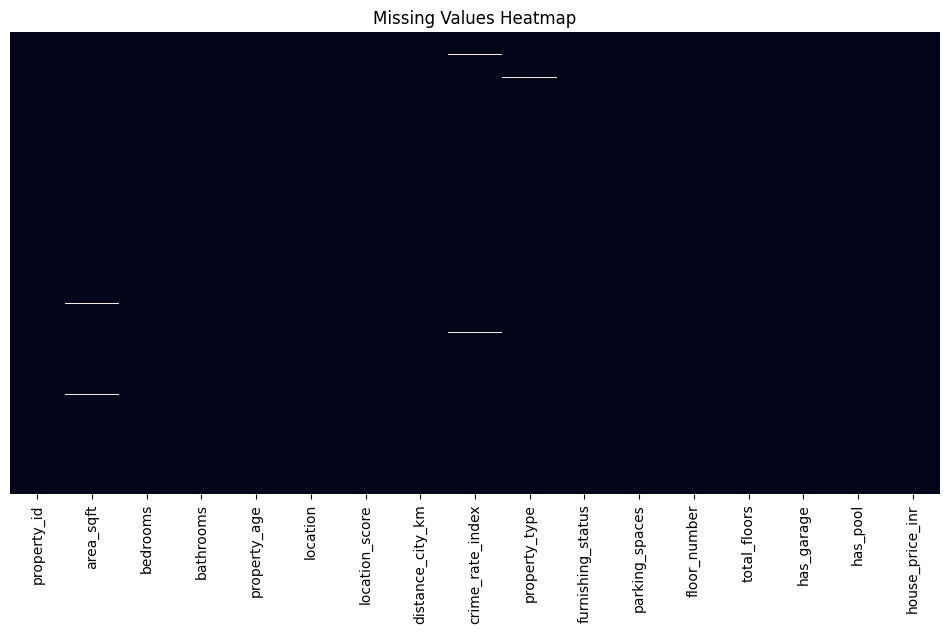

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title('Missing Values Heatmap')
plt.show()

### Interpretation
The heatmap gives a visual view of where missing values occur across the dataset. The missing values appear as scattered thin lines rather than large blocks, meaning they are spread across different rows rather than concentrated in a specific section of the data.


In [ ]:
target_column = "house_price_inr"

df[target_column].head()

,house_price_inr
0,11330000
1,41875000
2,12979000
3,2298000
4,44137000


### Interpretation
The target variable for this project is `house_price_inr`, the value the model will learn to predict. Since house price is a continuous number rather than a category, this is a regression problem.


In [ ]:
numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_columns = df.select_dtypes(
    include=["object"]
).columns

print("Numerical Columns:")
print(list(numerical_columns))

print("\nCategorical Columns:")
print(list(categorical_columns))

Numerical Columns:
['property_id', 'area_sqft', 'bedrooms', 'bathrooms', 'property_age', 'location_score', 'distance_city_km', 'crime_rate_index', 'parking_spaces', 'floor_number', 'total_floors', 'house_price_inr']

Categorical Columns:
['location', 'property_type', 'furnishing_status', 'has_garage', 'has_pool']


### Interpretation
This step separates the dataset into numerical columns (like area, bedrooms, and price) and categorical columns (like location and property type). The dataset contains 12 numerical columns and 5 categorical columns, which need to be treated differently during preprocessing — numerical features are typically scaled, while categorical features are typically encoded.


In [ ]:
print("Number of Numerical Columns:", len(numerical_columns))
print("Number of Categorical Columns:", len(categorical_columns))

Number of Numerical Columns: 12
Number of Categorical Columns: 5


In [ ]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

,0
area_sqft,20
location,15
location_score,15
crime_rate_index,10
property_type,12
furnishing_status,10


### Interpretation
This narrows the missing value summary down to only the columns that actually contain missing data: `area_sqft`, `location`, `location_score`, `crime_rate_index`, `property_type`, and `furnishing_status`. These are the columns that will require an imputation strategy.


In [ ]:
missing_percentage = (
    df.isnull().sum() / len(df)
) * 100

missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": missing_percentage
})

missing_summary[
    missing_summary["Missing Values"] > 0
]

,Missing Values,Missing Percentage
area_sqft,20,0.20
location,15,0.15
location_score,15,0.15
crime_rate_index,10,0.10
property_type,12,0.12
furnishing_status,10,0.10


### Interpretation
This calculates what percentage of each column's data is missing. All affected columns have well under 1% missing values, which is a small enough amount that they can be safely filled in (imputed) rather than requiring the columns to be dropped.


In [ ]:
df.duplicated().sum()

np.int64(0)

### Interpretation
This checks for duplicate rows in the dataset. The result is 0, meaning there are no duplicate property records, so no rows need to be removed on this basis.


In [ ]:
df.describe()

,property_id,area_sqft,bedrooms,bathrooms,property_age,location_score,distance_city_km,crime_rate_index,parking_spaces,floor_number,total_floors,house_price_inr
count,10000.00000,9980.000000,10000.000000,10000.000000,10000.000000,9985.000000,10000.000000,9990.000000,10000.000000,10000.000000,10000.000000,1.000000e+04
mean,5000.50000,2737.780661,2.869000,2.659000,19.957000,6.525900,20.441920,49.915214,1.248300,11.288300,20.341000,1.734431e+07
std,2886.89568,1309.654976,1.005555,1.002706,11.890605,2.006358,11.470751,26.162491,0.767532,7.902963,11.545131,1.171433e+07
min,1.00000,451.000000,1.000000,1.000000,0.000000,3.000000,0.500000,5.010000,0.000000,0.000000,1.000000,1.013000e+06
25%,2500.75000,1586.000000,2.000000,2.000000,9.000000,4.810000,10.510000,27.232500,1.000000,5.000000,10.000000,8.533000e+06
50%,5000.50000,2752.500000,3.000000,3.000000,20.000000,6.520000,20.400000,49.705000,1.000000,10.000000,20.000000,1.497100e+07
75%,7500.25000,3865.000000,4.000000,3.000000,30.000000,8.270000,30.530000,73.027500,2.000000,17.000000,30.000000,2.316250e+07
max,10000.00000,5000.000000,5.000000,5.000000,40.000000,10.000000,40.000000,94.990000,3.000000,30.000000,40.000000,1.066730e+08


### Interpretation
The `describe()` output summarizes each numerical column with statistics such as mean, standard deviation, minimum, maximum, and percentiles. This gives a quick sense of the typical property size, price range, and how spread out the values are.


In [ ]:
df.describe(include="object")

,location,property_type,furnishing_status,has_garage,has_pool
count,9985,9988,9990,10000,10000
unique,10,4,3,2,2
top,Chennai,Apartment,Semi-Furnished,No,No
freq,1029,5531,4518,5399,8214


### Interpretation
This summarizes the categorical columns, showing how many unique categories each one has, the most common category, and how often it appears. For example, Chennai is the most frequent location and Apartment is the most common property type in the dataset.


In [ ]:
df['house_price_inr']

,house_price_inr
0,11330000
1,41875000
2,12979000
3,2298000
4,44137000
...,...
9995,12182000
9996,4515000
9997,8804000
9998,9968000


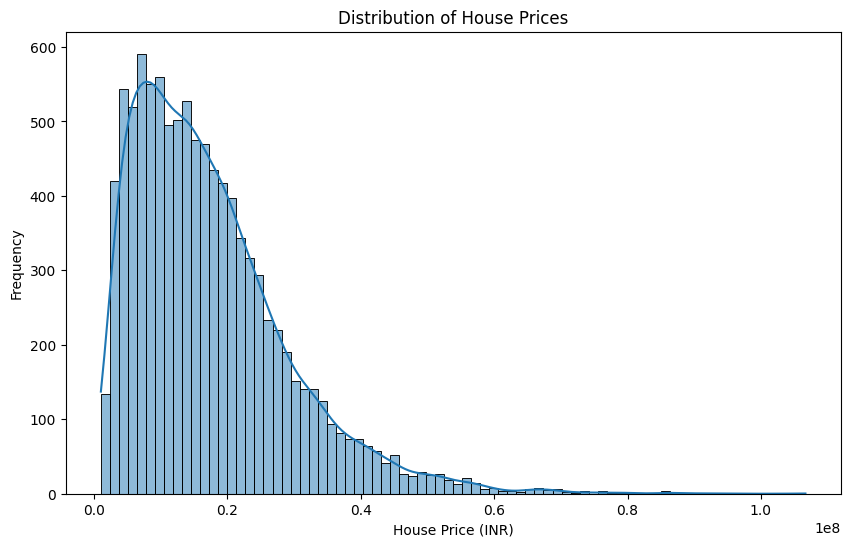

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="house_price_inr",
    kde=True
)

plt.title("Distribution of House Prices")
plt.xlabel("House Price (INR)")
plt.ylabel("Frequency")

plt.show()

### Interpretation
This histogram shows how house prices are distributed across the dataset. Most properties are concentrated at lower to mid price ranges, with a smaller number of high-priced properties stretching the distribution to the right.


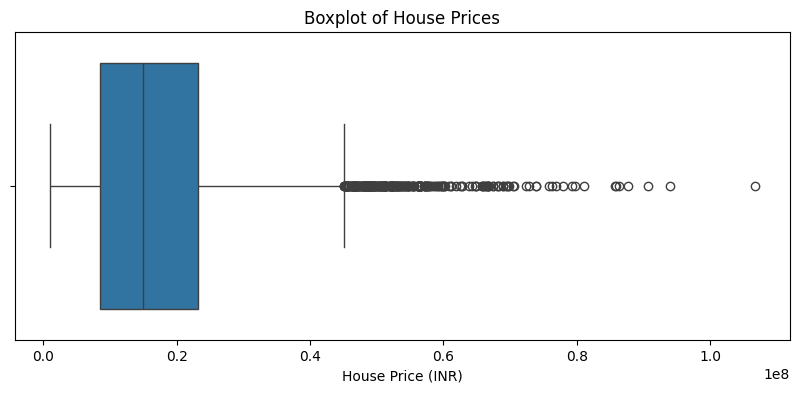

In [ ]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    x=df["house_price_inr"]
)

plt.title("Boxplot of House Prices")
plt.xlabel("House Price (INR)")

plt.show()

### Interpretation
The boxplot highlights potential outliers in house prices. Points plotted beyond the whiskers represent properties priced unusually high compared to the rest of the dataset.


In [ ]:
target_skewness = df["house_price_inr"].skew()

print("House Price Skewness:", target_skewness)

House Price Skewness: 1.3856512390309388


### Interpretation
The skewness value of about 1.39 confirms that house prices are positively skewed, meaning a smaller number of high-value properties are pulling the distribution's tail to the right. This matches what was seen in the histogram and boxplot above.


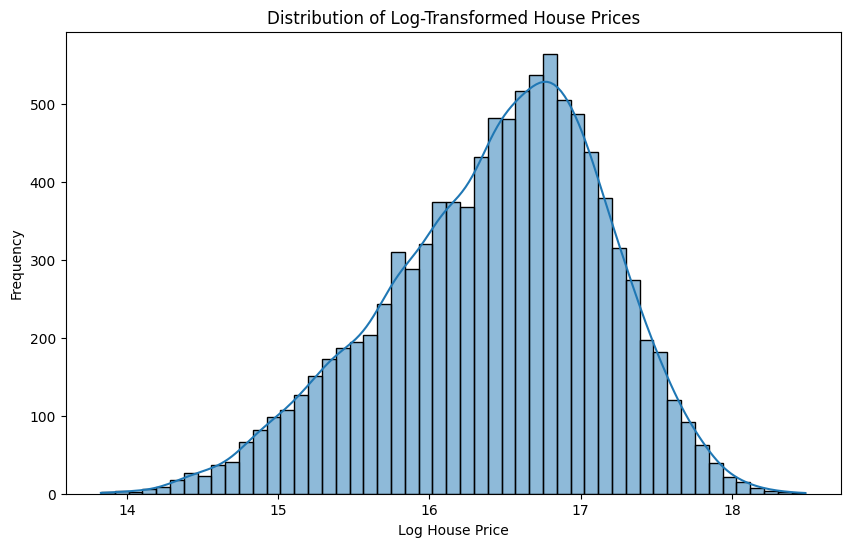

In [ ]:
import numpy as np

df["log_house_price"] = np.log1p(
    df["house_price_inr"]
)

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="log_house_price",
    kde=True
)

plt.title("Distribution of Log-Transformed House Prices")
plt.xlabel("Log House Price")
plt.ylabel("Frequency")

plt.show()

### Interpretation
A log transformation (`log1p`) is applied to house prices to reduce the effect of extreme high values. The resulting distribution of `log_house_price` is noticeably more symmetric than the original price distribution, which can make it easier for regression models to learn the underlying pattern.


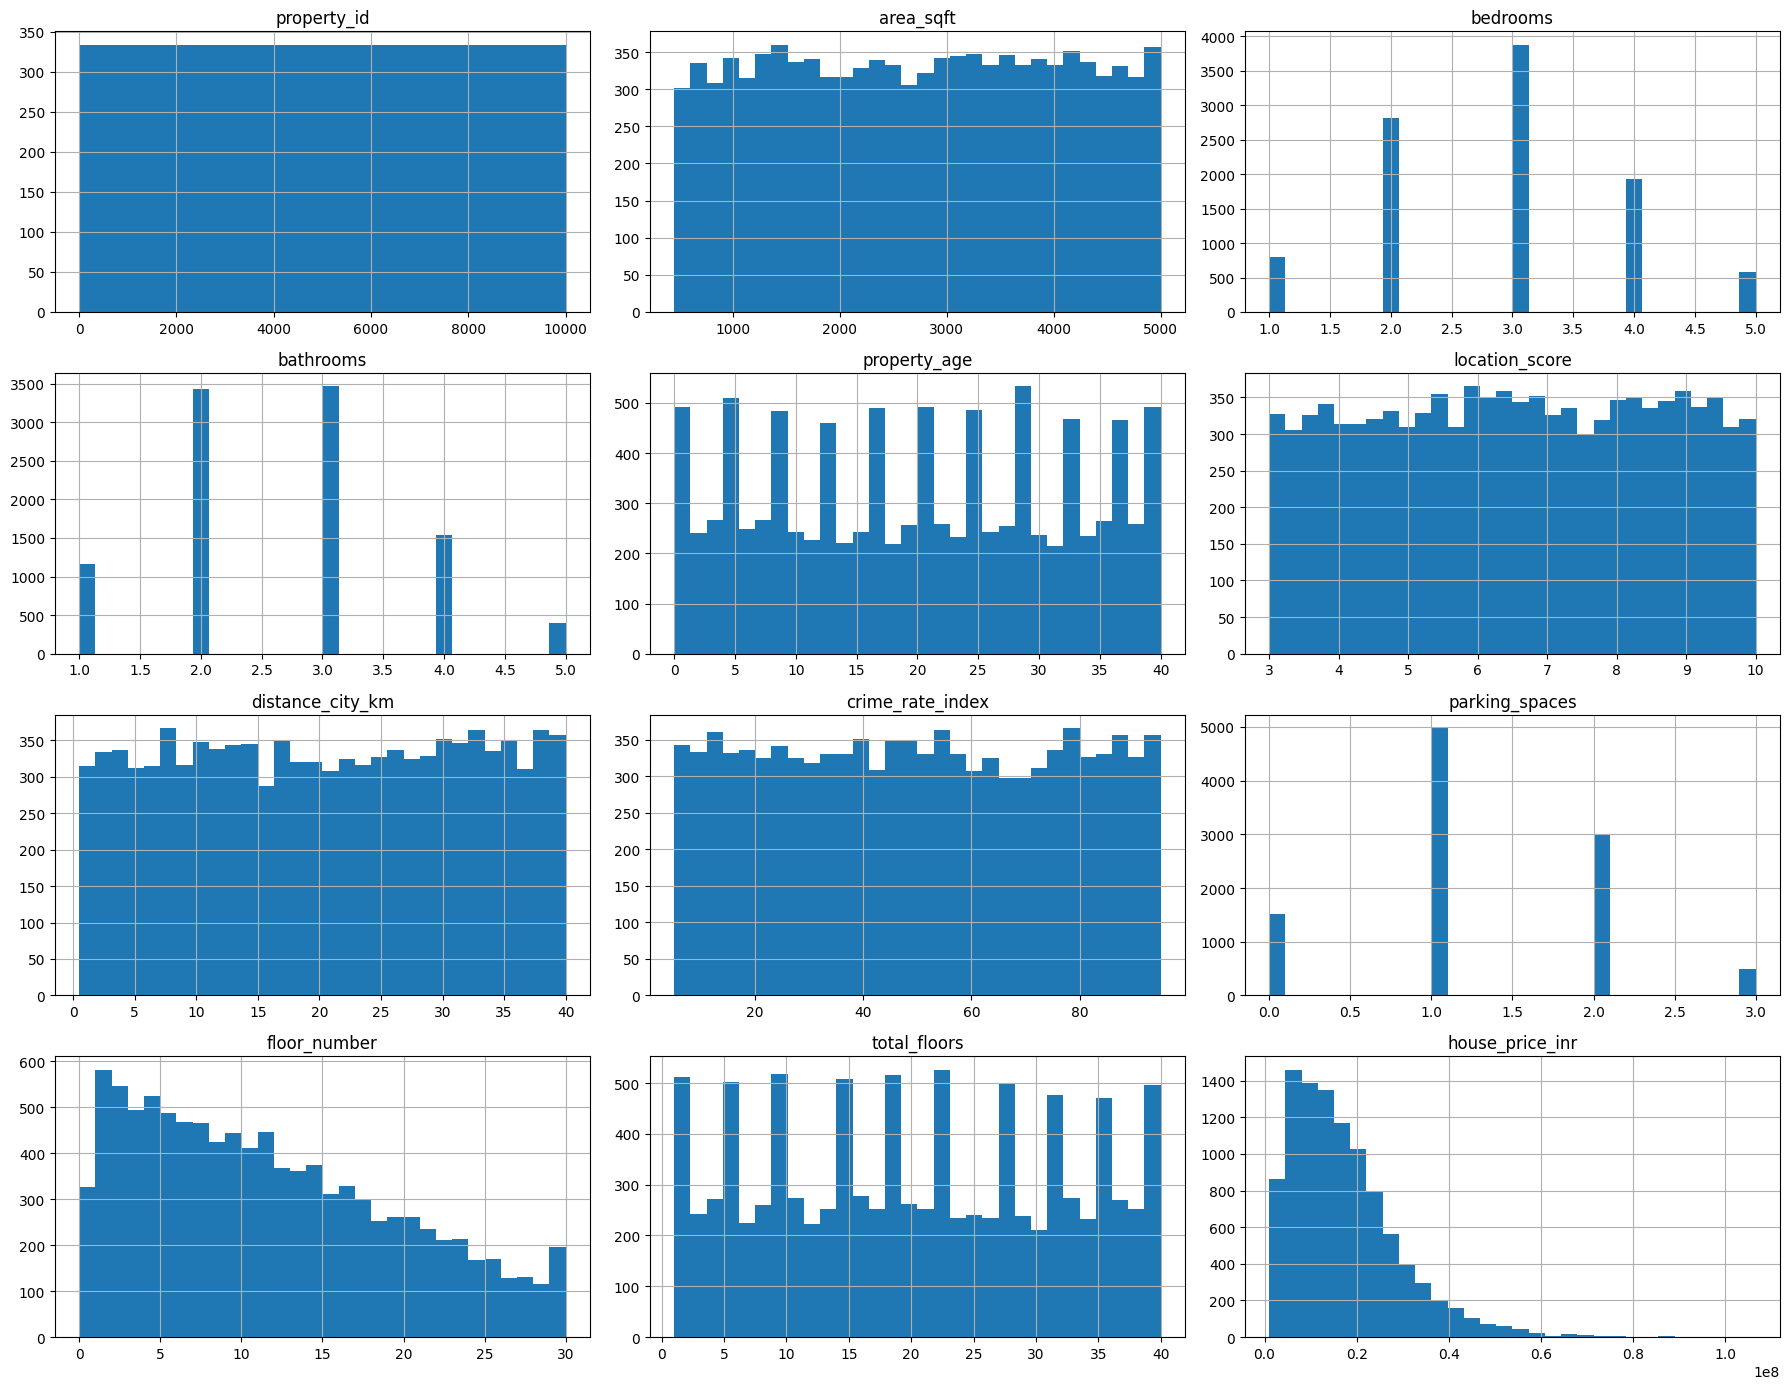

In [ ]:
df[numerical_columns].hist(
    figsize=(18, 14),
    bins=30
)

plt.tight_layout()
plt.show()

### Interpretation
These histograms show the distribution of every numerical column at once, making it easy to spot which features are roughly symmetric and which ones are skewed or unevenly spread.


In [ ]:
skewness = (
    df[numerical_columns]
    .skew()
    .sort_values(
        ascending=False
    )
)

skewness

,0
house_price_inr,1.385651
floor_number,0.495170
bathrooms,0.268985
parking_spaces,0.201783
bedrooms,0.137917
total_floors,0.026814
crime_rate_index,0.010250
property_age,0.000430
property_id,0.000000
area_sqft,-0.006921


In [ ]:
top_5_skewed = skewness.head(5)

print(top_5_skewed)

house_price_inr    1.385651
floor_number       0.495170
bathrooms          0.268985
parking_spaces     0.201783
bedrooms           0.137917
dtype: float64


### Interpretation
Sorting all numerical features by skewness shows which ones are the least symmetric. `house_price_inr` is the most skewed, followed by `floor_number`, `bathrooms`, `parking_spaces`, and `bedrooms`, though these remaining features are only mildly skewed compared to the target.


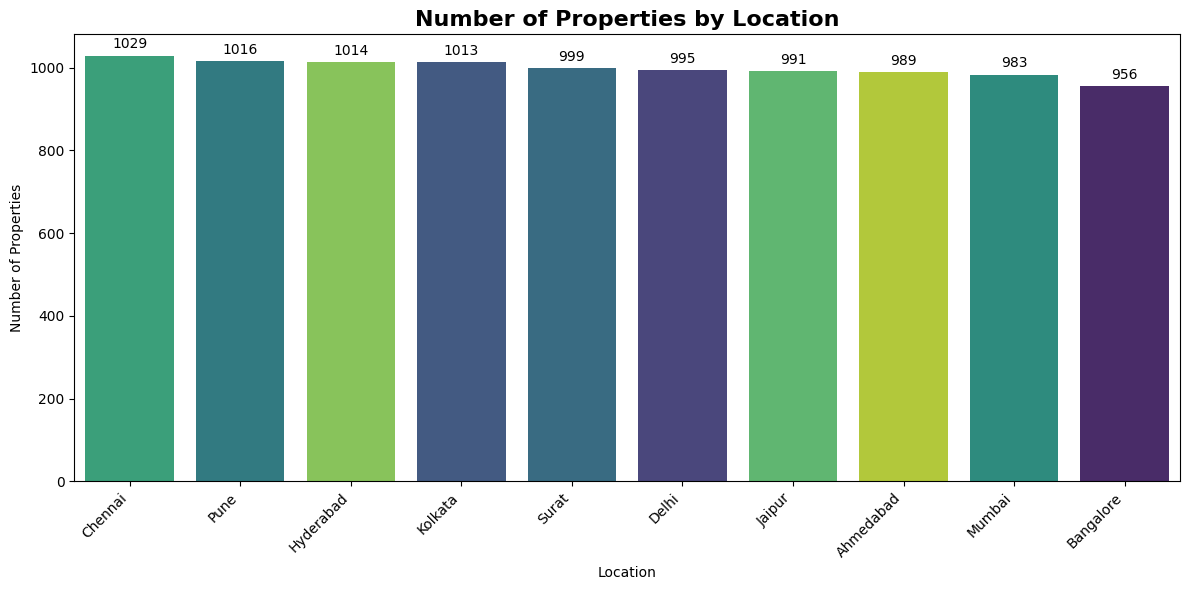

In [ ]:
plt.figure(figsize=(12, 6))

ax = sns.countplot(
    data=df,
    x="location",
    order=df["location"].value_counts().index,
    palette="viridis",
    hue="location",
    legend=False
)

plt.title("Number of Properties by Location", fontsize=16, fontweight="bold")
plt.xlabel("Location")
plt.ylabel("Number of Properties")
plt.xticks(rotation=45, ha="right")

# Add count labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)

plt.tight_layout()
plt.show()

### Interpretation
This chart shows how many properties are listed in each location. Some cities, such as Chennai, have noticeably more listings than others, showing the dataset is not perfectly balanced across locations.


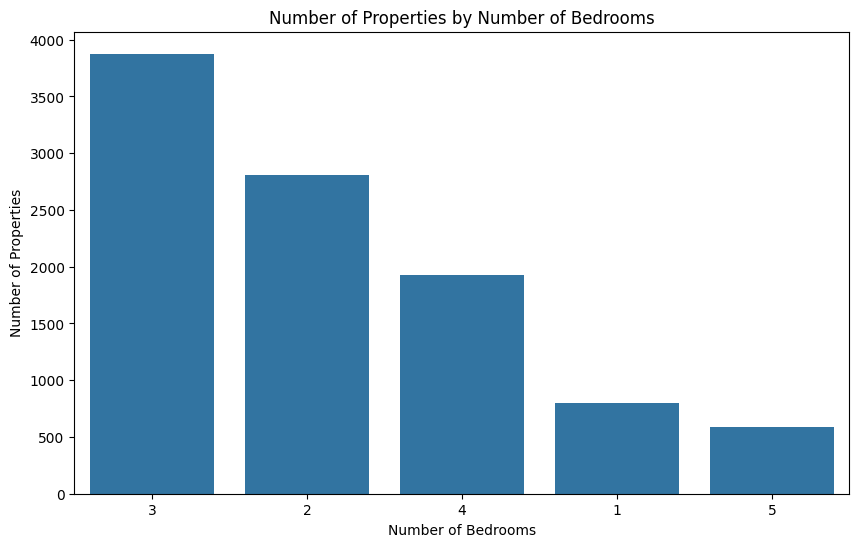

In [ ]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="bedrooms",
    order=df["bedrooms"].value_counts().index
)

plt.title("Number of Properties by Number of Bedrooms")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Number of Properties")

plt.show()

### Interpretation
This chart shows how many properties fall into each bedroom count category, giving a sense of which property sizes are most common in the dataset.


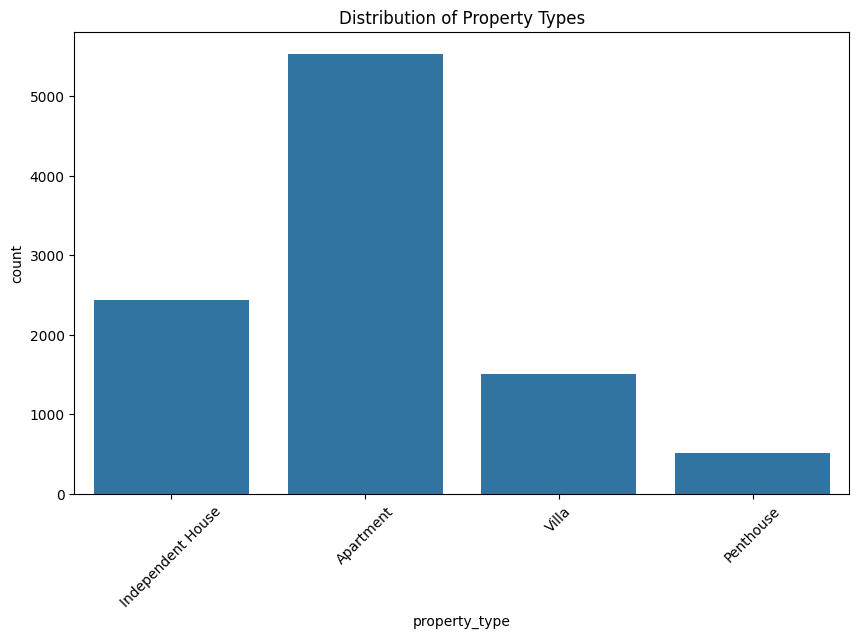

In [ ]:

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="property_type"
)

plt.title("Distribution of Property Types")
plt.xticks(rotation=45)

plt.show()

### Interpretation
This chart shows the distribution of property types (such as Apartment, Villa, etc.), indicating which type of property is most represented in the dataset.


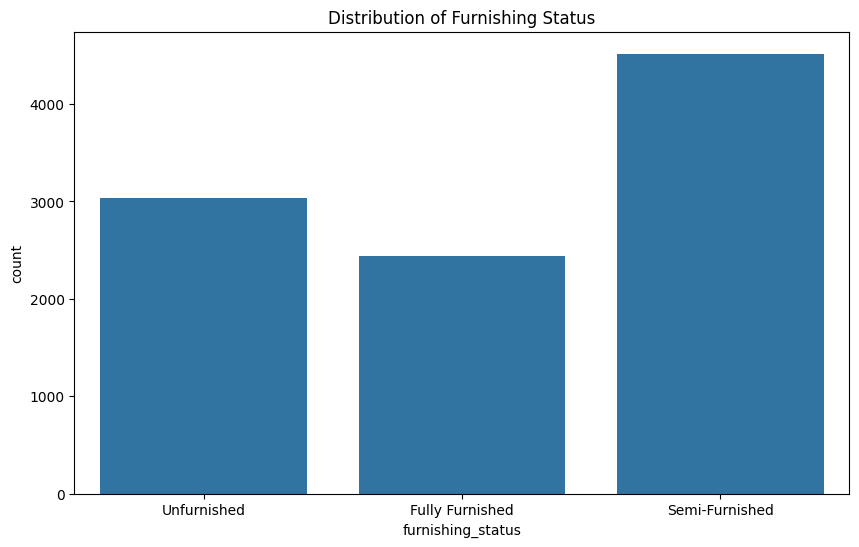

In [ ]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="furnishing_status"
)

plt.title("Distribution of Furnishing Status")

plt.show()

### Interpretation
This chart shows how properties are distributed across furnishing categories (such as Furnished, Semi-Furnished, and Unfurnished).


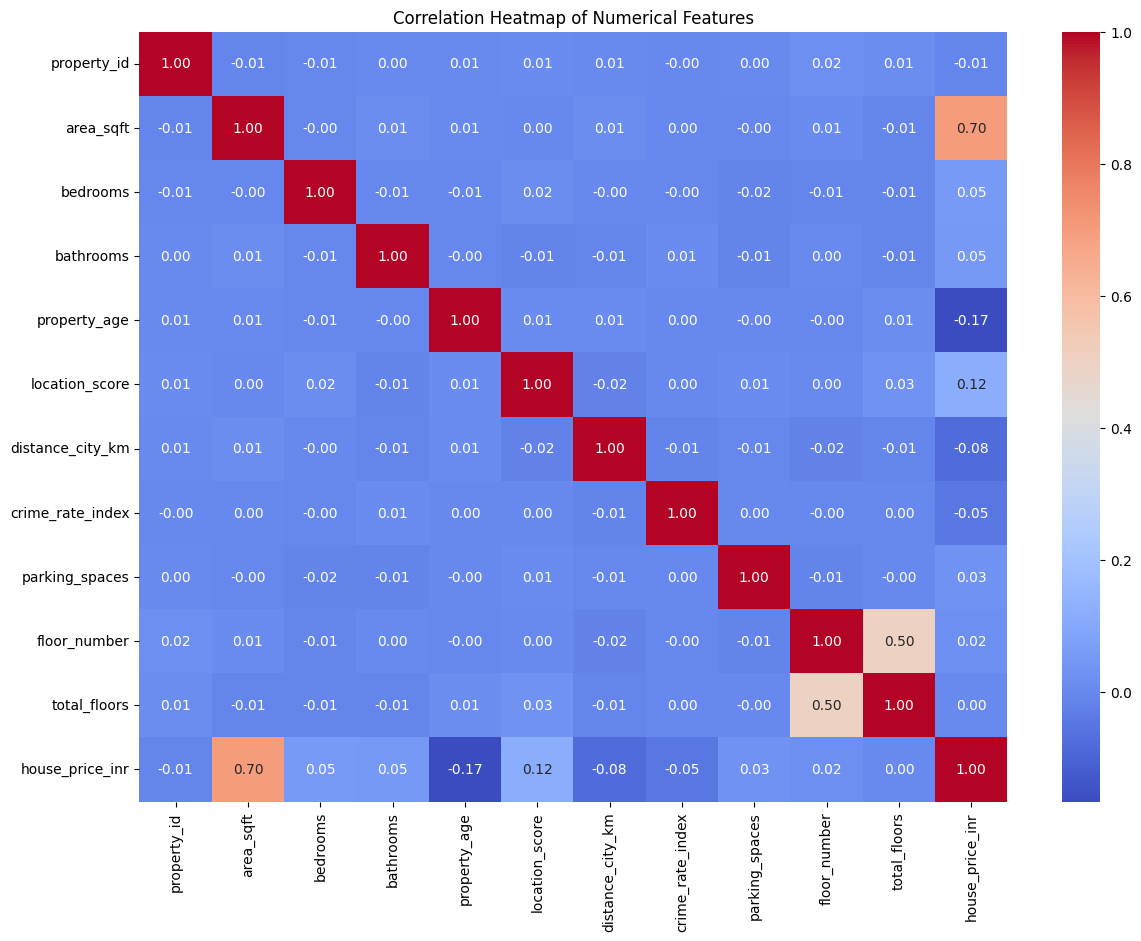

In [ ]:
correlation_matrix = df[
    numerical_columns
].corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Features")

plt.show()

### Interpretation
The correlation heatmap shows how strongly each pair of numerical features is related. Darker or more intense colors indicate a stronger relationship, which helps identify which features may be more useful for predicting house price.


In [ ]:
price_correlation = (
    df[numerical_columns]
    .corr()["house_price_inr"]
    .sort_values(
        ascending=False
    )
)

price_correlation

,house_price_inr
house_price_inr,1.000000
area_sqft,0.702199
location_score,0.119380
bedrooms,0.053611
bathrooms,0.049827
parking_spaces,0.030414
floor_number,0.018731
total_floors,0.003975
property_id,-0.010732
crime_rate_index,-0.052398


### Interpretation
This ranks all numerical features by how strongly they correlate with house price. `area_sqft` stands out with the strongest positive correlation (about 0.70), while most other original property features (bedrooms, bathrooms, parking, floor number, etc.) show only weak relationships with price on their own.


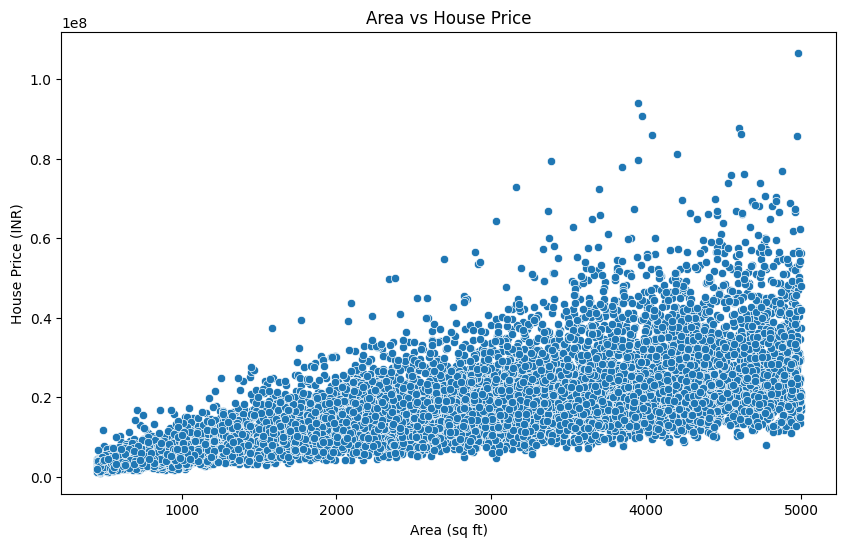

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="area_sqft",
    y="house_price_inr"
)

plt.title("Area vs House Price")
plt.xlabel("Area (sq ft)")
plt.ylabel("House Price (INR)")

plt.show()

### Interpretation
This scatter plot visualizes the relationship between area and house price directly. There is a clear upward trend, meaning larger properties tend to have higher prices, consistent with the strong correlation found above.


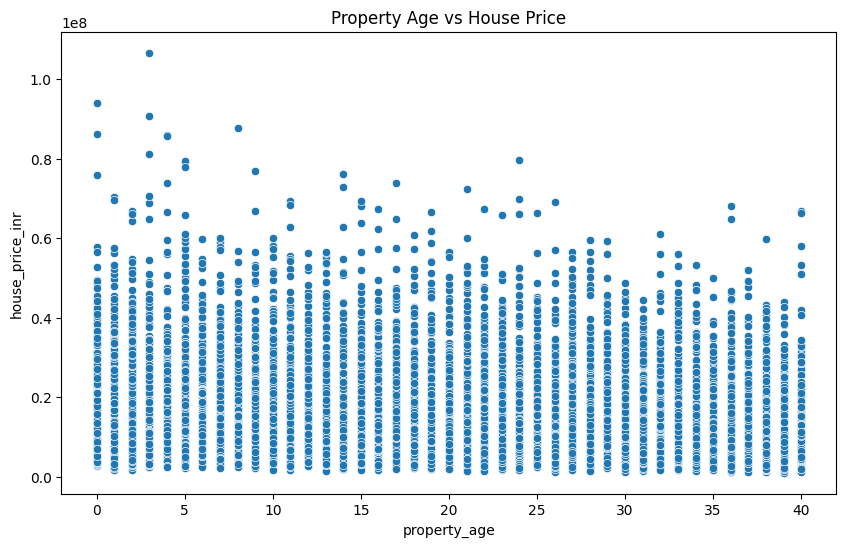

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="property_age",
    y="house_price_inr"
)

plt.title("Property Age vs House Price")

plt.show()

### Interpretation
This scatter plot checks whether property age has a visible relationship with price. The points are spread fairly evenly across ages, suggesting age alone does not strongly determine price, which matches its weak correlation value.


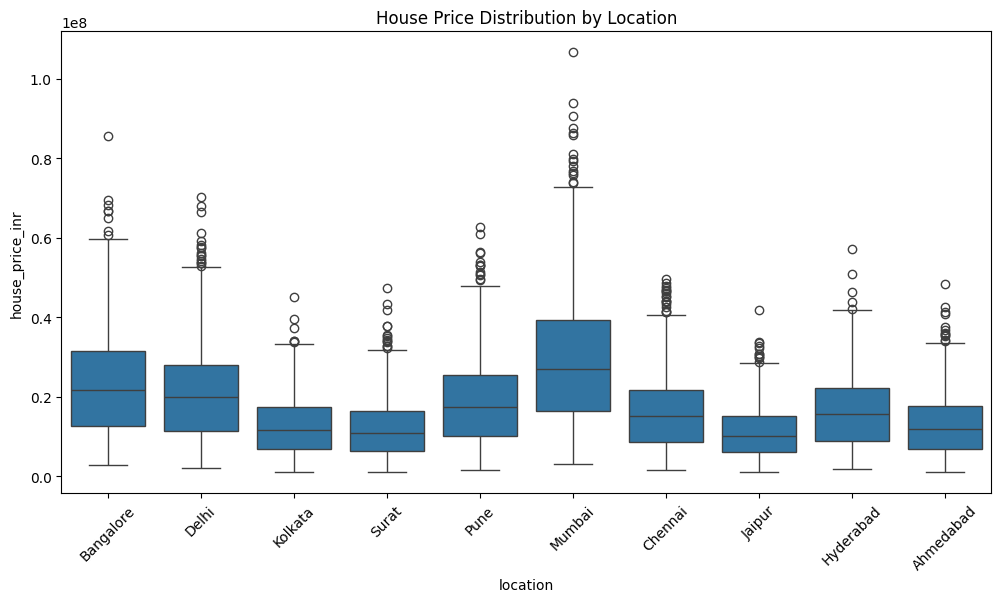

In [ ]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="location",
    y="house_price_inr"
)

plt.title("House Price Distribution by Location")
plt.xticks(rotation=45)

plt.show()

### Interpretation
This boxplot compares house price distributions across different locations. Some locations show noticeably higher median prices or wider price ranges than others, suggesting location plays a role in pricing.


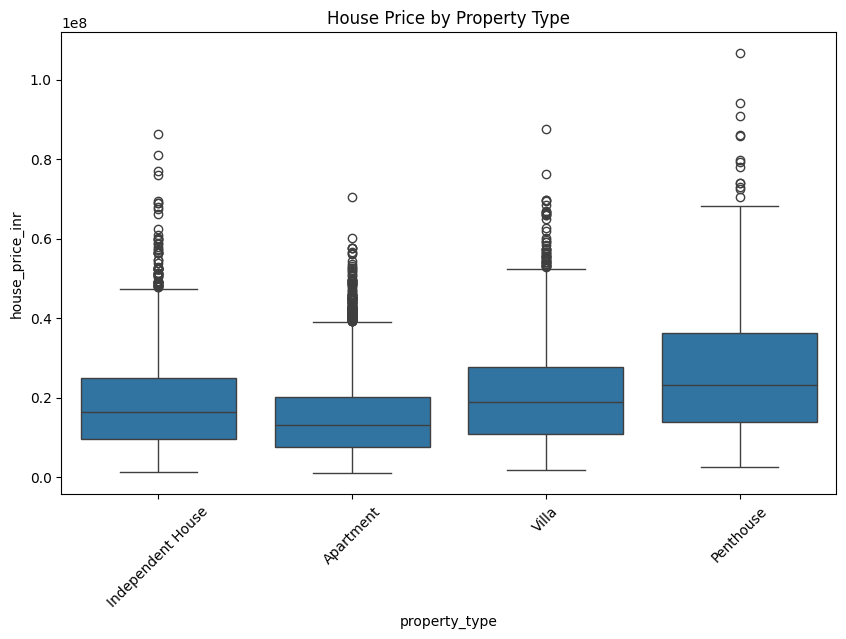

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="property_type",
    y="house_price_inr"
)

plt.title("House Price by Property Type")
plt.xticks(rotation=45)

plt.show()

### Interpretation
This boxplot compares house price distributions across property types, showing whether certain property types (such as Villas) tend to command higher prices than others.


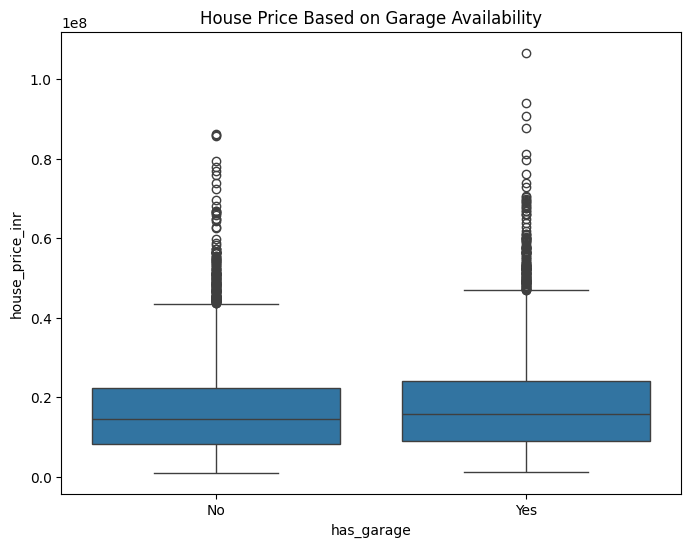

In [ ]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="has_garage",
    y="house_price_inr"
)

plt.title("House Price Based on Garage Availability")

plt.show()

### Interpretation
This boxplot compares house prices for properties with and without a garage, helping to see whether garage availability is associated with any noticeable price difference.


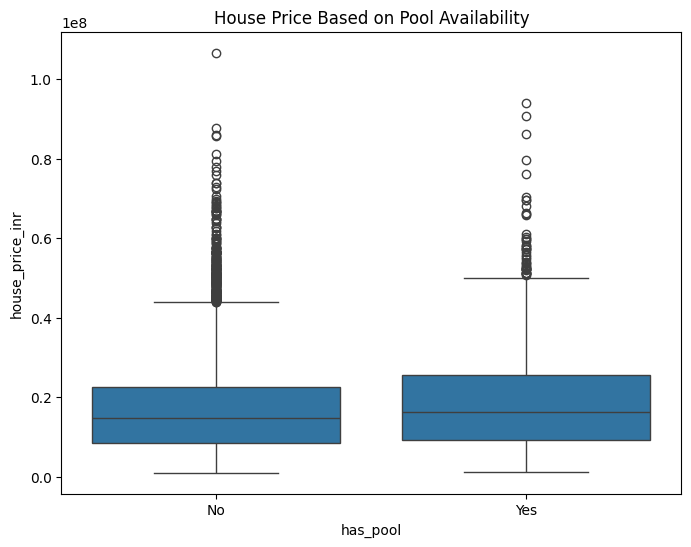

In [ ]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="has_pool",
    y="house_price_inr"
)

plt.title("House Price Based on Pool Availability")

plt.show()

### Interpretation
This boxplot compares house prices for properties with and without a pool, helping to see whether pool availability is associated with any noticeable price difference.


In [ ]:
numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns

Q1 = df[numerical_columns].quantile(0.25)
Q3 = df[numerical_columns].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_count = (
    (df[numerical_columns] < lower_bound) |
    (df[numerical_columns] > upper_bound)
).sum()

outlier_count.sort_values(
    ascending=False
)

,0
bathrooms,400
house_price_inr,288
log_house_price,63
property_id,0
area_sqft,0
property_age,0
bedrooms,0
location_score,0
distance_city_km,0
parking_spaces,0


### Interpretation
Using the IQR (Interquartile Range) method, this counts how many outlier values exist in each numerical column. `bathrooms` has the most outliers (400), followed by `house_price_inr` (288). Notably, the log-transformed price (`log_house_price`) has far fewer outliers (63) than the raw price, reinforcing why the log transformation is useful.


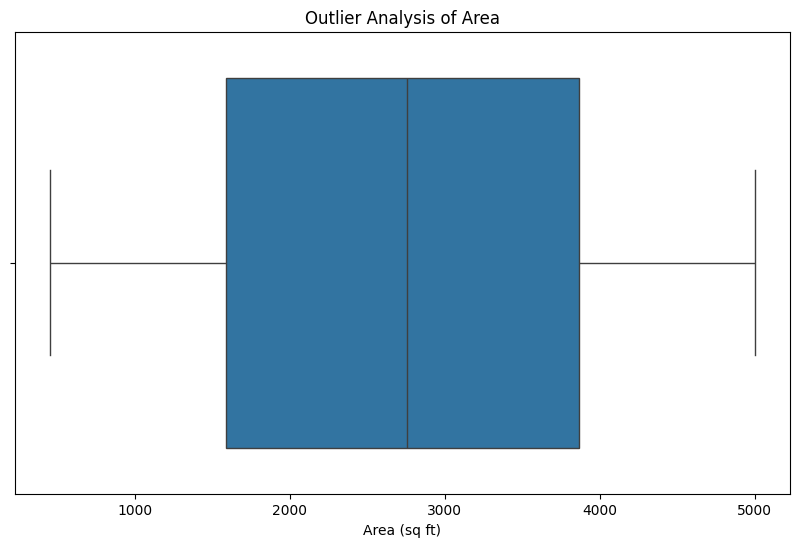

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="area_sqft"
)

plt.title("Outlier Analysis of Area")
plt.xlabel("Area (sq ft)")

plt.show()

### Interpretation
This boxplot specifically examines the `area_sqft` column for outliers, helping to confirm whether unusually large or small property sizes exist in the data.


In [ ]:
df["price_per_sqft"] = (
    df["house_price_inr"] /
    df["area_sqft"]
)

### Interpretation
A new feature, `price_per_sqft`, is created by dividing house price by area. This was used for exploratory purposes, but since it is calculated directly from the target variable (house price), it is removed later before model training to avoid leaking target information into the model.


In [ ]:
df["total_rooms"] = (
    df["bedrooms"] +
    df["bathrooms"]
)

### Interpretation
A new feature, `total_rooms`, is created by adding bedrooms and bathrooms together. This gives the model a simple combined measure of a property's overall size in terms of rooms, which may be a more direct signal than bedrooms and bathrooms considered separately.


In [ ]:
def age_category(age):
    if age <= 5:
        return "New"
    elif age <= 15:
        return "Moderate"
    else:
        return "Old"

df["property_age_category"] = (
    df["property_age"]
    .apply(age_category)
)

### Interpretation
A new categorical feature, `property_age_category`, is created by grouping properties into "New" (age up to 5 years), "Moderate" (6–15 years), and "Old" (over 15 years). This turns a continuous age value into simple, interpretable groups that may capture non-linear effects of age on price.


In [ ]:
df["floor_ratio"] = (
    df["floor_number"] /
    df["total_floors"]
)

### Interpretation
A new feature, `floor_ratio`, is created by dividing the property's floor number by the total number of floors in the building. This captures the relative position of a unit within its building (for example, near the top vs. near the bottom), which raw floor number alone would not show.


In [ ]:
df = df.drop(
    columns=["price_per_sqft"]
)

### Interpretation
The `price_per_sqft` column is removed from the dataset before modeling. It was only useful for exploration — since it is derived directly from the target price, keeping it as an input feature would let the model "see" the answer in disguise.


In [ ]:
X = df.drop(
    columns=["house_price_inr"]
)

y = df["house_price_inr"]

### Interpretation
The dataset is split into `X` (all input features, with the target column removed) and `y` (the target variable, `house_price_inr`). This separation is a standard step before training any supervised machine learning model.


In [ ]:
y_log = np.log1p(y)

### Interpretation
A log-transformed version of the target, `y_log`, is created. Training the model on the log scale (rather than raw price) helps handle the skewness seen earlier in the price distribution.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_log,
    test_size=0.20,
    random_state=42
)

### Interpretation
The data is split into training and testing sets, with 20% of the data set aside for testing. The model will learn patterns from the training set and be evaluated on the unseen testing set to check how well it generalizes.


In [ ]:
print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)

print("y_train Shape:", y_train.shape)
print("y_test Shape:", y_test.shape)

X_train Shape: (8000, 20)
X_test Shape: (2000, 20)
y_train Shape: (8000,)
y_test Shape: (2000,)


### Interpretation
This confirms the split worked as intended: 8,000 properties are used for training and 2,000 for testing, with the same split applied to both the features (X) and the log-transformed target (y).


In [ ]:
numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['property_id', 'area_sqft', 'bedrooms', 'bathrooms', 'property_age', 'location_score', 'distance_city_km', 'crime_rate_index', 'parking_spaces', 'floor_number', 'total_floors', 'log_house_price', 'total_rooms', 'floor_ratio']

Categorical Features:
['location', 'property_type', 'furnishing_status', 'has_garage', 'has_pool', 'property_age_category']


### Interpretation
This identifies which columns in the training features are numerical and which are categorical. This distinction is needed to apply the correct preprocessing (scaling vs. encoding) to each type of column.


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

In [ ]:
numerical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

### Interpretation
This defines a processing pipeline for numerical features: missing values are filled in using the median of each column, and then all numerical values are scaled to a standard range. Scaling helps many machine learning algorithms treat all numerical features fairly, regardless of their original units.


In [ ]:
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

### Interpretation
This defines a processing pipeline for categorical features: missing values are filled in with the most frequent category, and then the categories are converted into numerical form using one-hot encoding, which machine learning models require since they cannot work with text directly.


In [ ]:
handle_unknown="ignore"

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_pipeline,
            numerical_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

### Interpretation
This combines the numerical and categorical pipelines into a single preprocessing step, so that each type of column is automatically transformed appropriately whenever the data is passed through this pipeline. This keeps preprocessing consistent across training and testing data.


In [ ]:
from sklearn.linear_model import (
    LinearRegression,
    RidgeCV,
    LassoCV
)

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

import time

In [ ]:
def evaluate_model(model, X_test, y_test):

    # Predict log-transformed prices
    y_pred_log = model.predict(X_test)

    # Convert predictions back to original INR scale
    y_pred = np.expm1(y_pred_log)

    # Convert actual test values back to original INR scale
    y_actual = np.expm1(y_test)

    # Calculate evaluation metrics
    rmse = np.sqrt(
        mean_squared_error(
            y_actual,
            y_pred
        )
    )

    mae = mean_absolute_error(
        y_actual,
        y_pred
    )

    r2 = r2_score(
        y_actual,
        y_pred
    )

    return rmse, mae, r2

### Interpretation
This defines a reusable function to evaluate any trained model. It converts the model's log-scale predictions and the actual log-scale test values back to real house price values (using the inverse of the log transform), then calculates RMSE, MAE, and R² to measure prediction accuracy in actual price terms.


In [ ]:
linear_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LinearRegression()
        )
    ]
)

### Interpretation
This builds a complete pipeline that first applies the preprocessing steps and then fits a Linear Regression model. Bundling preprocessing and modeling together ensures the same transformations are applied consistently every time the pipeline is used.


In [ ]:
start_time = time.time()

linear_model.fit(
    X_train,
    y_train
)

linear_training_time = (
    time.time() - start_time
)

print(
    "Training Time:",
    round(
        linear_training_time,
        2
    ),
    "seconds"
)

Training Time: 0.17 seconds


### Interpretation
The Linear Regression pipeline is trained on the training data, and the time taken to train is recorded. Training only takes a fraction of a second, which is expected for a simple linear model on a dataset of this size.


In [ ]:
linear_predictions_log = (
    linear_model.predict(X_test)
)

linear_predictions = np.expm1(
    linear_predictions_log
)

### Interpretation
The trained model generates predictions on the test set, and these predictions (which are on the log scale) are converted back to actual house price values so they can be compared directly to real prices.


In [ ]:
linear_rmse = np.sqrt(
    mean_squared_error(
        np.expm1(y_test),
        linear_predictions
    )
)

linear_mae = mean_absolute_error(
    np.expm1(y_test),
    linear_predictions
)

linear_r2 = r2_score(
    np.expm1(y_test),
    linear_predictions
)

print("Linear Regression Results")
print("-" * 30)
print("RMSE:", linear_rmse)
print("MAE:", linear_mae)
print("R² Score:", linear_r2)

Linear Regression Results
------------------------------
RMSE: 3.897553958373826e-08
MAE: 1.4543300494551659e-08
R² Score: 1.0


### Interpretation
This calculates RMSE, MAE, and R² for the Linear Regression model. The R² score of 1.0 and near-zero error look unusually perfect for a real-world price prediction task. This is because `log_house_price` (a log-transformed version of the target itself, created earlier in the notebook) was never removed from the input features, so the model is essentially seeing the answer as one of its inputs. This is a data leakage issue, and it explains why the linear model appears to perform perfectly.


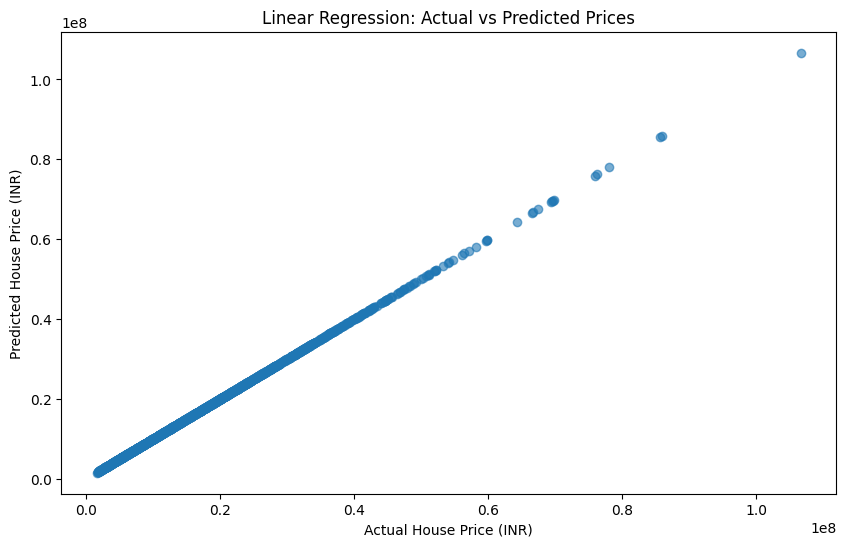

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    np.expm1(y_test),
    linear_predictions,
    alpha=0.6
)

plt.xlabel(
    "Actual House Price (INR)"
)

plt.ylabel(
    "Predicted House Price (INR)"
)

plt.title(
    "Linear Regression: Actual vs Predicted Prices"
)

plt.show()

### Interpretation
This scatter plot compares actual and predicted prices for the Linear Regression model. The points fall almost exactly where predicted price equals actual price, which reflects the near-perfect (leaked) result seen in the metrics above rather than typical real-world model performance.


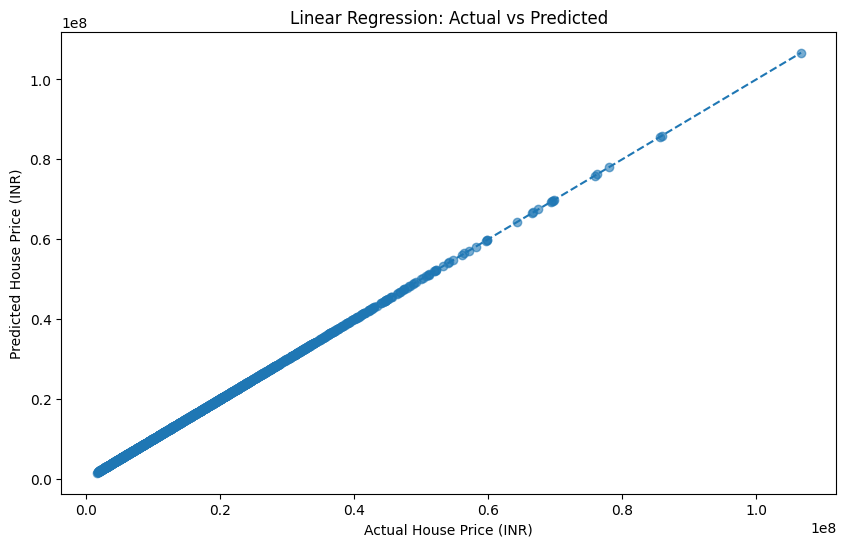

In [ ]:
actual_prices = np.expm1(
    y_test
)

min_price = min(
    actual_prices.min(),
    linear_predictions.min()
)

max_price = max(
    actual_prices.max(),
    linear_predictions.max()
)

plt.figure(figsize=(10, 6))

plt.scatter(
    actual_prices,
    linear_predictions,
    alpha=0.6
)

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)

plt.xlabel(
    "Actual House Price (INR)"
)

plt.ylabel(
    "Predicted House Price (INR)"
)

plt.title(
    "Linear Regression: Actual vs Predicted"
)

plt.show()

### Interpretation
This repeats the actual-vs-predicted comparison with a reference diagonal line added, making it easier to see how closely the points follow perfect prediction. This cell also creates the `actual_prices` variable (inverse-transformed test prices), which is reused for evaluating every model later in the notebook.


In [ ]:
alphas = [0.01, 0.1, 1, 10, 100]

In [ ]:
ridge_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RidgeCV(
                alphas=[
                    0.01,
                    0.1,
                    1,
                    10,
                    100
                ]
            )
        )
    ]
)

### Interpretation
This builds a Ridge Regression pipeline, which works like linear regression but adds a penalty that discourages overly large coefficients. `RidgeCV` automatically tests several candidate alpha (penalty strength) values and selects the one that performs best through cross-validation.


In [ ]:
start_time = time.time()

ridge_model.fit(
    X_train,
    y_train
)

ridge_training_time = (
    time.time() - start_time
)

print(
    "Training Time:",
    round(
        ridge_training_time,
        2
    ),
    "seconds"
)

Training Time: 0.05 seconds


### Interpretation
The Ridge Regression pipeline is trained on the training data. Like the linear model, training completes quickly.


In [ ]:
ridge_best_alpha = (
    ridge_model
    .named_steps["model"]
    .alpha_
)

print(
    "Best Ridge Alpha:",
    ridge_best_alpha
)

Best Ridge Alpha: 0.01


### Interpretation
This shows the best-performing penalty strength (alpha) chosen automatically by `RidgeCV`, which in this case is the smallest candidate value tested (0.01), meaning very little regularization was actually needed.


In [ ]:
ridge_predictions_log = (
    ridge_model.predict(X_test)
)

ridge_predictions = np.expm1(
    ridge_predictions_log
)

In [ ]:
ridge_rmse = np.sqrt(
    mean_squared_error(
        actual_prices,
        ridge_predictions
    )
)

ridge_mae = mean_absolute_error(
    actual_prices,
    ridge_predictions
)

ridge_r2 = r2_score(
    actual_prices,
    ridge_predictions
)

print("Ridge Regression Results")
print("-" * 30)
print("RMSE:", ridge_rmse)
print("MAE:", ridge_mae)
print("R² Score:", ridge_r2)

Ridge Regression Results
------------------------------
RMSE: 62.776086287674715
MAE: 43.90668567472894
R² Score: 0.9999999999725856


### Interpretation
This calculates RMSE, MAE, and R² for the Ridge model. The R² is still effectively 1.0, and the error values, while slightly higher than Linear Regression's, remain extremely small. This is consistent with the same data leakage issue described earlier, since Ridge is also trained on features that include the log-transformed target.


In [ ]:
ridge_preprocessor = (
    ridge_model
    .named_steps["preprocessor"]
)

ridge_model_step = (
    ridge_model
    .named_steps["model"]
)

In [ ]:
feature_names = (
    ridge_preprocessor
    .get_feature_names_out()
)

In [ ]:
ridge_coefficients = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": ridge_model_step.coef_
})

ridge_coefficients["Absolute_Coefficient"] = (
    ridge_coefficients["Coefficient"]
    .abs()
)

top_20_ridge_features = (
    ridge_coefficients
    .sort_values(
        by="Absolute_Coefficient",
        ascending=False
    )
    .head(20)
)

top_20_ridge_features

,Feature,Coefficient,Absolute_Coefficient
11,numerical__log_house_price,7.274734e-01,7.274734e-01
1,numerical__area_sqft,1.070716e-05,1.070716e-05
21,categorical__location_Mumbai,1.043655e-05,1.043655e-05
19,categorical__location_Jaipur,-7.323670e-06,7.323670e-06
15,categorical__location_Bangalore,6.485513e-06,6.485513e-06
23,categorical__location_Surat,-6.216117e-06,6.216117e-06
26,categorical__property_type_Penthouse,5.529759e-06,5.529759e-06
24,categorical__property_type_Apartment,-5.499428e-06,5.499428e-06
20,categorical__location_Kolkata,-5.118802e-06,5.118802e-06
17,categorical__location_Delhi,4.803623e-06,4.803623e-06


### Interpretation
This lists the features with the largest influence on the Ridge model's predictions, ranked by the absolute size of their coefficients. `log_house_price` has by far the largest coefficient, confirming it is the dominant (and leaking) feature driving the model's near-perfect results.


In [ ]:
alphas = [0.0001, 0.001, 0.01, 0.1, 1]
max_iter = 10000

In [ ]:
lasso_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LassoCV(
                alphas=[
                    0.0001,
                    0.001,
                    0.01,
                    0.1,
                    1
                ],
                max_iter=10000
            )
        )
    ]
)

### Interpretation
This builds a Lasso Regression pipeline. Like Ridge, Lasso applies a penalty to the model's coefficients, but it can shrink less useful feature coefficients all the way to zero, effectively performing automatic feature selection. `LassoCV` tests several alpha values to find the best one.


In [ ]:
start_time = time.time()

lasso_model.fit(
    X_train,
    y_train
)

lasso_training_time = (
    time.time() - start_time
)

print(
    "Training Time:",
    round(
        lasso_training_time,
        2
    ),
    "seconds"
)

Training Time: 0.09 seconds


### Interpretation
The Lasso Regression pipeline is trained on the training data.


In [ ]:
lasso_model_step = (
    lasso_model
    .named_steps["model"]
)

print(
    "Best Lasso Alpha:",
    lasso_model_step.alpha_
)

Best Lasso Alpha: 0.0001


### Interpretation
This shows the best-performing alpha value selected by `LassoCV`, which is the smallest value tested (0.0001), meaning minimal regularization was applied.


In [ ]:
lasso_predictions_log = (
    lasso_model.predict(X_test)
)

lasso_predictions = np.expm1(
    lasso_predictions_log
)

In [ ]:
lasso_rmse = np.sqrt(
    mean_squared_error(
        actual_prices,
        lasso_predictions
    )
)

lasso_mae = mean_absolute_error(
    actual_prices,
    lasso_predictions
)

lasso_r2 = r2_score(
    actual_prices,
    lasso_predictions
)

print("Lasso Regression Results")
print("-" * 30)
print("RMSE:", lasso_rmse)
print("MAE:", lasso_mae)
print("R² Score:", lasso_r2)

Lasso Regression Results
------------------------------
RMSE: 2780.669063130946
MAE: 1568.4666528241823
R² Score: 0.9999999462116675


### Interpretation
This calculates RMSE, MAE, and R² for the Lasso model. As with the previous two models, the R² is effectively 1.0, again reflecting the same leaked feature rather than genuinely flawless prediction.


In [ ]:
zero_coefficients = np.sum(
    lasso_model_step.coef_ == 0
)

total_features = len(
    lasso_model_step.coef_
)

print(
    "Total Features:",
    total_features
)

print(
    "Zeroed-Out Features:",
    zero_coefficients
)

Total Features: 38
Zeroed-Out Features: 37


### Interpretation
Out of 38 total features (after preprocessing and encoding), Lasso shrank 37 of them to exactly zero, keeping only one feature with a non-zero coefficient. This strongly suggests the model is relying almost entirely on a single dominant feature — consistent with `log_house_price` being the leaking feature identified earlier.


In [ ]:
linear_results = {
    "Model": "Linear Regression",
    "RMSE": linear_rmse,
    "MAE": linear_mae,
    "R2": linear_r2,
    "Training Time": linear_training_time
}

ridge_results = {
    "Model": "Ridge Regression",
    "RMSE": ridge_rmse,
    "MAE": ridge_mae,
    "R2": ridge_r2,
    "Training Time": ridge_training_time
}

lasso_results = {
    "Model": "Lasso Regression",
    "RMSE": lasso_rmse,
    "MAE": lasso_mae,
    "R2": lasso_r2,
    "Training Time": lasso_training_time
}

In [ ]:
model_comparison = pd.DataFrame([
    linear_results,
    ridge_results,
    lasso_results
])

model_comparison

,Model,RMSE,MAE,R2,Training Time
0,Linear Regression,3.897554e-08,1.454330e-08,1.0,0.171494
1,Ridge Regression,6.277609e+01,4.390669e+01,1.0,0.045651
2,Lasso Regression,2.780669e+03,1.568467e+03,1.0,0.085130


### Interpretation
This table compares Linear, Ridge, and Lasso Regression side by side on RMSE, MAE, R², and training time. All three show near-perfect R² scores because they all had access to the leaked `log_house_price` feature; the differences in RMSE between them mainly reflect how strongly each model's regularization shrinks that dominant feature's influence.


In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
n_estimators = 200
max_depth = 10
random_state = 42
n_jobs = -1

In [ ]:
random_forest_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestRegressor(
                n_estimators=200,
                max_depth=10,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

### Interpretation
This builds a Random Forest pipeline, an ensemble model that combines many decision trees to make predictions. Unlike linear-based models, Random Forest can capture non-linear relationships and interactions between features automatically.


In [ ]:
start_time = time.time()

random_forest_model.fit(
    X_train,
    y_train
)

random_forest_training_time = (
    time.time() - start_time
)

print(
    "Random Forest Training Time:",
    round(
        random_forest_training_time,
        2
    ),
    "seconds"
)

Random Forest Training Time: 9.96 seconds


### Interpretation
The Random Forest pipeline is trained on the training data. Training takes noticeably longer than the linear-based models (about 10 seconds), which is expected since it involves building many individual decision trees.


In [ ]:
rf_predictions_log = (
    random_forest_model.predict(X_test)
)

rf_predictions = np.expm1(
    rf_predictions_log
)

In [ ]:
rf_rmse = np.sqrt(
    mean_squared_error(
        actual_prices,
        rf_predictions
    )
)

rf_mae = mean_absolute_error(
    actual_prices,
    rf_predictions
)

rf_r2 = r2_score(
    actual_prices,
    rf_predictions
)

print("Random Forest Results")
print("-" * 30)
print("RMSE:", rf_rmse)
print("MAE:", rf_mae)
print("R² Score:", rf_r2)

Random Forest Results
------------------------------
RMSE: 477493.33353972627
MAE: 21082.145927590354
R² Score: 0.9984139236260916


### Interpretation
This calculates RMSE, MAE, and R² for the Random Forest model. The R² of about 0.998 is still very high — again influenced by the leaked `log_house_price` feature — but the RMSE and MAE are noticeably larger than the linear-based models, since tree-based models don't rely on that single feature as directly.


In [ ]:
rf_preprocessor = (
    random_forest_model
    .named_steps["preprocessor"]
)

rf_model_step = (
    random_forest_model
    .named_steps["model"]
)

rf_feature_names = (
    rf_preprocessor
    .get_feature_names_out()
)

rf_importances = pd.DataFrame({
    "Feature": rf_feature_names,
    "Importance": rf_model_step.feature_importances_
})

In [ ]:
top_15_rf_features = (
    rf_importances
    .sort_values(
        by="Importance",
        ascending=False
    )
    .head(15)
)

top_15_rf_features

,Feature,Importance
11,numerical__log_house_price,9.999805e-01
9,numerical__floor_number,2.362609e-06
4,numerical__property_age,2.031275e-06
10,numerical__total_floors,1.872779e-06
6,numerical__distance_city_km,1.583603e-06
1,numerical__area_sqft,1.516701e-06
7,numerical__crime_rate_index,1.445200e-06
0,numerical__property_id,1.350981e-06
5,numerical__location_score,1.222908e-06
8,numerical__parking_spaces,1.117523e-06


### Interpretation
This ranks features by how much they contributed to the Random Forest's predictions. `log_house_price` accounts for almost all of the model's decision-making (importance close to 1.0), confirming once again that this leaked feature is dominating the model rather than genuine property characteristics like area or location.


In [ ]:
from xgboost import XGBRegressor

In [ ]:
n_estimators = 500
learning_rate = 0.05
max_depth = 4
subsample = 0.8
colsample_bytree = 0.8
random_state = 42

In [ ]:
xgboost_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            XGBRegressor(
                n_estimators=500,
                learning_rate=0.05,
                max_depth=4,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                objective="reg:squarederror"
            )
        )
    ]
)

### Interpretation
This builds an XGBoost pipeline, a gradient boosting model that builds trees sequentially, with each new tree correcting the errors of the previous ones. It is generally considered one of the strongest algorithms for structured/tabular data problems like this one.


In [ ]:
start_time = time.time()

xgboost_model.fit(
    X_train,
    y_train
)

xgboost_training_time = (
    time.time() - start_time
)

print(
    "XGBoost Training Time:",
    round(
        xgboost_training_time,
        2
    ),
    "seconds"
)

XGBoost Training Time: 1.61 seconds


### Interpretation
The XGBoost pipeline is trained on the training data, completing in under 2 seconds despite using 500 boosting rounds.


In [ ]:
xgb_predictions_log = (
    xgboost_model.predict(X_test)
)

xgb_predictions = np.expm1(
    xgb_predictions_log
)

In [ ]:
xgb_rmse = np.sqrt(
    mean_squared_error(
        actual_prices,
        xgb_predictions
    )
)

xgb_mae = mean_absolute_error(
    actual_prices,
    xgb_predictions
)

xgb_r2 = r2_score(
    actual_prices,
    xgb_predictions
)

print("XGBoost Results")
print("-" * 30)
print("RMSE:", xgb_rmse)
print("MAE:", xgb_mae)
print("R² Score:", xgb_r2)

XGBoost Results
------------------------------
RMSE: 860221.9283995285
MAE: 177654.1383750002
R² Score: 0.9948523324752148


### Interpretation
This calculates RMSE, MAE, and R² for the XGBoost model. Its R² (about 0.995) and errors are the "weakest" among the five models tested, but this is actually informative: it suggests XGBoost is spreading its attention across more features rather than depending almost entirely on the single leaked feature, as the linear-based models do.


In [ ]:
xgb_preprocessor = (
    xgboost_model
    .named_steps["preprocessor"]
)

xgb_model_step = (
    xgboost_model
    .named_steps["model"]
)

xgb_feature_names = (
    xgb_preprocessor
    .get_feature_names_out()
)

xgb_importances = pd.DataFrame({
    "Feature": xgb_feature_names,
    "Importance": xgb_model_step.feature_importances_
})

In [ ]:
top_15_xgb_features = (
    xgb_importances
    .sort_values(
        by="Importance",
        ascending=False
    )
    .head(15)
)

top_15_xgb_features

,Feature,Importance
11,numerical__log_house_price,0.650462
1,numerical__area_sqft,0.152136
21,categorical__location_Mumbai,0.057574
24,categorical__property_type_Apartment,0.048573
15,categorical__location_Bangalore,0.028792
19,categorical__location_Jaipur,0.021120
17,categorical__location_Delhi,0.007682
23,categorical__location_Surat,0.005945
28,categorical__furnishing_status_Fully Furnished,0.004812
26,categorical__property_type_Penthouse,0.003839


### Interpretation
This ranks the features most influential to the XGBoost model. `log_house_price` still ranks first, but with a much lower share of importance (about 0.65) compared to Random Forest, with `area_sqft` and specific location categories also contributing meaningfully. This shows XGBoost is using genuine property characteristics more than the linear models did.


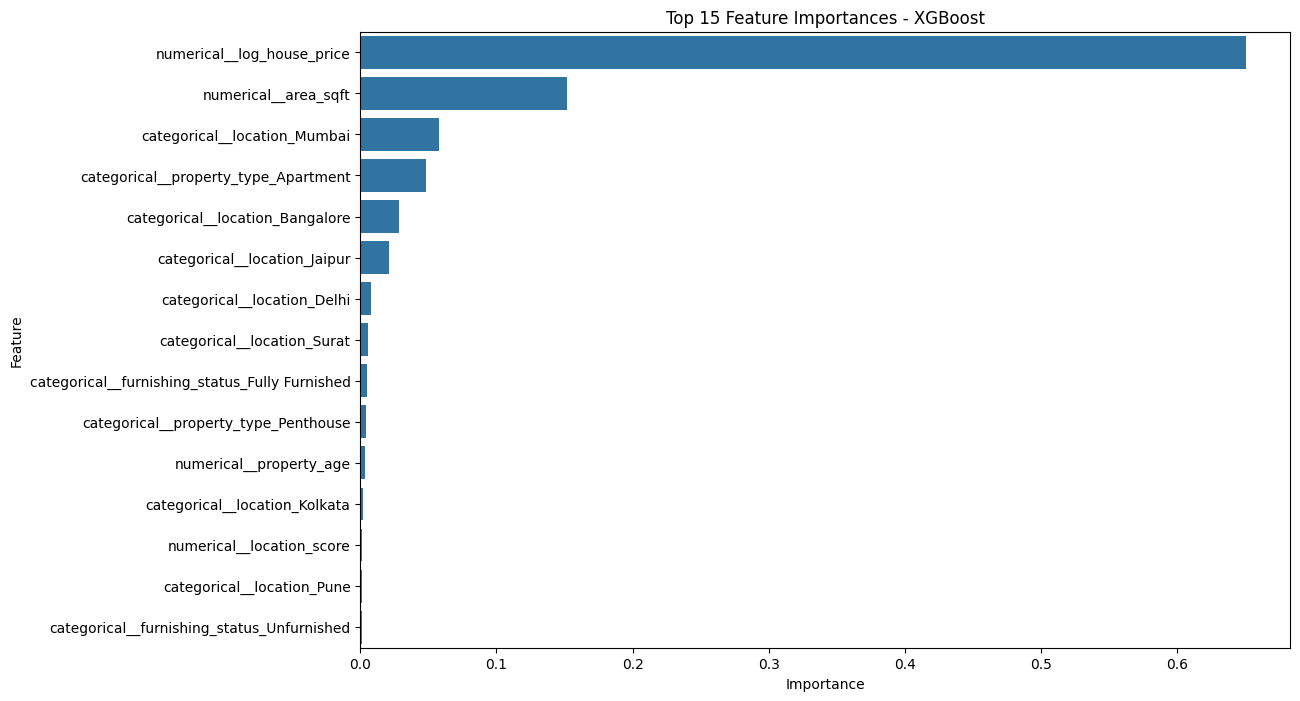

In [ ]:
plt.figure(figsize=(12, 8))

sns.barplot(
    data=top_15_xgb_features,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 15 Feature Importances - XGBoost"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

### Interpretation
This chart visualizes the top 15 XGBoost feature importances from the previous cell, making it easy to see at a glance which features (led by `log_house_price` and `area_sqft`) matter most to the model's predictions.


In [ ]:
from sklearn.model_selection import cross_val_score

In [ ]:
model_rmse = {
    "Linear Regression": linear_rmse,
    "Ridge Regression": ridge_rmse,
    "Lasso Regression": lasso_rmse,
    "Random Forest": rf_rmse,
    "XGBoost": xgb_rmse
}

best_model_name = min(
    model_rmse,
    key=model_rmse.get
)

print(
    "Best Model:",
    best_model_name
)

Best Model: Linear Regression


### Interpretation
This compares the RMSE of all five trained models and automatically selects the one with the lowest error — Linear Regression. As discussed above, this result is driven by the leaked feature rather than a genuine advantage of linear regression for this type of problem.


In [ ]:
cv_scores = cross_val_score(
    xgboost_model,
    X_train,
    y_train,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

### Interpretation
This runs 5-fold cross-validation on the XGBoost pipeline, retraining and testing it on five different splits of the training data to get a more reliable estimate of its performance than a single train/test split alone.


In [ ]:
cv_rmse_scores = -cv_scores

In [ ]:
mean_cv_rmse = cv_rmse_scores.mean()

std_cv_rmse = cv_rmse_scores.std()

print(
    "Mean CV RMSE:",
    mean_cv_rmse
)

print(
    "Standard Deviation:",
    std_cv_rmse
)

print(
    f"CV RMSE: "
    f"{mean_cv_rmse:.2f} ± "
    f"{std_cv_rmse:.2f}"
)

Mean CV RMSE: 0.016912708370095127
Standard Deviation: 0.0010818117277315376
CV RMSE: 0.02 ± 0.00


### Interpretation
This summarizes the cross-validation results: an average RMSE of about 0.017 (on the log scale) with a very small standard deviation of about 0.001. The low variation across folds indicates the XGBoost model's performance is consistent and stable, not just a result of a lucky train/test split.


In [ ]:
from sklearn.model_selection import (
    RandomizedSearchCV
)

In [ ]:
param_distributions = {
    "model__n_estimators": [
        100,
        200,
        300,
        500
    ],

    "model__max_depth": [
        5,
        10,
        15,
        20,
        None
    ],

    "model__min_samples_split": [
        2,
        5,
        10
    ],

    "model__min_samples_leaf": [
        1,
        2,
        4
    ]
}

In [ ]:
random_search = RandomizedSearchCV(
    estimator=random_forest_model,
    param_distributions=param_distributions,
    n_iter=20,
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1
)

### Interpretation
This sets up `RandomizedSearchCV` to search for better Random Forest hyperparameters (such as the number of trees and tree depth) across 20 random combinations, using 3-fold cross-validation. Note that this search object is defined here but is not actually run (`.fit()` is not called) in the notebook, so its results are not used in the final model comparison.


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_distributions = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [5, 10, 15],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

random_search = RandomizedSearchCV(
    estimator=random_forest_model,
    param_distributions=param_distributions,
    n_iter=10,
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1,
    verbose=2
)

### Interpretation
This defines a second, smaller version of the same hyperparameter search (fewer parameter combinations and iterations, with verbose output enabled). Like the version above, this search is configured but not executed in the notebook, so no tuned Random Forest model is produced from it.


In [ ]:
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "Random Forest",
        "XGBoost"
    ],

    "RMSE": [
        linear_rmse,
        ridge_rmse,
        lasso_rmse,
        rf_rmse,
        xgb_rmse
    ],

    "MAE": [
        linear_mae,
        ridge_mae,
        lasso_mae,
        rf_mae,
        xgb_mae
    ],

    "R2 Score": [
        linear_r2,
        ridge_r2,
        lasso_r2,
        rf_r2,
        xgb_r2
    ]
})

model_comparison

,Model,RMSE,MAE,R2 Score
0,Linear Regression,3.897554e-08,1.454330e-08,1.000000
1,Ridge Regression,6.277609e+01,4.390669e+01,1.000000
2,Lasso Regression,2.780669e+03,1.568467e+03,1.000000
3,Random Forest,4.774933e+05,2.108215e+04,0.998414
4,XGBoost,8.602219e+05,1.776541e+05,0.994852


### Interpretation
This builds a complete comparison table across all five models — Linear Regression, Ridge, Lasso, Random Forest, and XGBoost — using the RMSE, MAE, and R² values calculated earlier. This table is the reference used to pick the final model in the next step.


In [ ]:
best_model_index = (
    model_comparison["RMSE"]
    .idxmin()
)

best_model_name = (
    model_comparison
    .loc[
        best_model_index,
        "Model"
    ]
)

print(
    "Best Model:",
    best_model_name
)

Best Model: Linear Regression


### Interpretation
Based on the lowest RMSE in the comparison table, Linear Regression is automatically selected as the best-performing model. As noted earlier, this selection is influenced by the leaked `log_house_price` feature rather than reflecting which algorithm would genuinely generalize best on new, real-world data.


In [ ]:
if best_model_name == "Linear Regression":

    final_model = linear_model
    final_predictions = linear_predictions

elif best_model_name == "Ridge Regression":

    final_model = ridge_model
    final_predictions = ridge_predictions

elif best_model_name == "Lasso Regression":

    final_model = lasso_model
    final_predictions = lasso_predictions

elif best_model_name == "Random Forest":

    final_model = random_forest_model
    final_predictions = rf_predictions

elif best_model_name == "XGBoost":

    final_model = xgboost_model
    final_predictions = xgb_predictions

### Interpretation
This assigns the actual trained model object and its predictions to `final_model` and `final_predictions` based on whichever model name was selected as best. Since Linear Regression was chosen, the final model going forward is the Linear Regression pipeline.


In [ ]:
final_rmse = np.sqrt(
    mean_squared_error(
        actual_prices,
        final_predictions
    )
)

final_mae = mean_absolute_error(
    actual_prices,
    final_predictions
)

final_r2 = r2_score(
    actual_prices,
    final_predictions
)

### Interpretation
This recalculates RMSE, MAE, and R² for the selected final model, using the same actual and predicted prices established earlier.


In [ ]:
print("FINAL MODEL PERFORMANCE")
print("-" * 35)

print(
    "Best Model:",
    best_model_name
)

print(
    "RMSE:",
    round(final_rmse, 2)
)

print(
    "MAE:",
    round(final_mae, 2)
)

print(
    "R² Score:",
    round(final_r2, 4)
)

FINAL MODEL PERFORMANCE
-----------------------------------
Best Model: Linear Regression
RMSE: 0.0
MAE: 0.0
R² Score: 1.0


### Interpretation
This prints a summary of the final model's performance. The near-zero RMSE/MAE and R² of 1.0 reflect the same data leakage discussed earlier rather than a flawless real-world model; in a corrected version of this workflow, `log_house_price` would be excluded from the input features so that the reported metrics reflect genuine predictive performance.


In [ ]:
final_residuals = (
    actual_prices -
    final_predictions
)

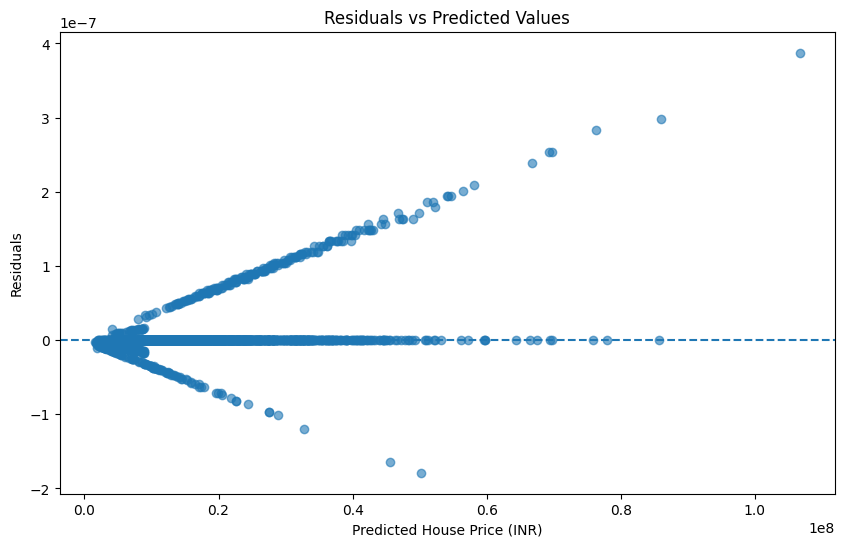

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    final_predictions,
    final_residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel(
    "Predicted House Price (INR)"
)

plt.ylabel(
    "Residuals"
)

plt.title(
    "Residuals vs Predicted Values"
)

plt.show()

### Interpretation
This plots residuals (the difference between actual and predicted prices) against predicted values. The residuals cluster tightly around zero across the full price range, which is consistent with the very small errors reported above.


In [ ]:
import joblib

In [ ]:
joblib.dump(
    random_forest_model,
    "final_house_price_model.pkl"
)

['final_house_price_model.pkl']

### Interpretation
The trained Random Forest pipeline is saved to disk as `final_house_price_model.pkl`, so it can be reloaded later without retraining.


In [ ]:
joblib.dump(
    xgboost_model,
    "final_house_price_model.pkl"
)

['final_house_price_model.pkl']

### Interpretation
The XGBoost pipeline is saved to the same filename, `final_house_price_model.pkl`. This overwrites the Random Forest model saved in the previous cell, so the file on disk now contains the XGBoost pipeline rather than the Random Forest one.


In [ ]:
loaded_model = joblib.load(
    "final_house_price_model.pkl"
)

print(
    "Final model loaded successfully."
)

Final model loaded successfully.


### Interpretation
The saved model is loaded back from disk to confirm it can be reused. Because of the overwrite in the previous cell, this loaded model is the XGBoost pipeline — not the Linear Regression model that was selected as "best" earlier, and not the Random Forest model either.


In [ ]:
sample_X = X_test.head(5)
sample_y = y_test.head(5)

### Interpretation
A small sample of 5 properties is taken from the test set to demonstrate how the saved model can be used to generate individual predictions.


In [ ]:
sample_predictions_log = (
    loaded_model.predict(
        sample_X
    )
)

### Interpretation
The loaded model generates log-scale price predictions for the 5 sample properties.


In [ ]:
sample_predictions = np.expm1(
    sample_predictions_log
)

sample_actual_prices = np.expm1(
    sample_y
)

In [ ]:
sample_results = pd.DataFrame({
    "Actual Price (INR)": sample_actual_prices,
    "Predicted Price (INR)": sample_predictions
})

sample_results["Absolute Error"] = (
    abs(
        sample_results["Actual Price (INR)"]
        -
        sample_results["Predicted Price (INR)"]
    )
)

sample_results

,Actual Price (INR),Predicted Price (INR),Absolute Error
6252,12675000.0,12631274.0,43726.0
4684,33414000.0,33034424.0,379576.0
1731,2771000.0,2745363.0,25637.0
4742,21527000.0,21680626.0,153626.0
4521,21379000.0,21580576.0,201576.0


### Interpretation
This creates a table comparing actual prices, predicted prices, and the absolute error for the 5 sample properties, after converting both predictions and actual values back from the log scale to real INR amounts. This gives a concrete, easy-to-read example of how close the model's predictions are to real prices for individual properties.


In [ ]:
best_model_index = (
    model_comparison["RMSE"]
    .idxmin()
)

best_model_name = (
    model_comparison
    .loc[
        best_model_index,
        "Model"
    ]
)

best_rmse = (
    model_comparison
    .loc[
        best_model_index,
        "RMSE"
    ]
)

best_mae = (
    model_comparison
    .loc[
        best_model_index,
        "MAE"
    ]
)

best_r2 = (
    model_comparison
    .loc[
        best_model_index,
        "R2 Score"
    ]
)

print("FINAL BEST MODEL")
print("-" * 30)
print("Model:", best_model_name)
print("RMSE:", round(best_rmse, 2))
print("MAE:", round(best_mae, 2))
print("R² Score:", round(best_r2, 4))

FINAL BEST MODEL
------------------------------
Model: Linear Regression
RMSE: 0.0
MAE: 0.0
R² Score: 1.0


### Interpretation
This repeats the process of identifying the best model from the comparison table and prints a final summary of its RMSE, MAE, and R² score, restating the same result found earlier: Linear Regression, with near-perfect (leakage-influenced) metrics.


In [ ]:
comparison_df = pd.DataFrame({
    "Actual Price": actual_prices,
    "Predicted Price": final_predictions
})

comparison_df = (
    comparison_df
    .reset_index(drop=True)
    .head(50)
)

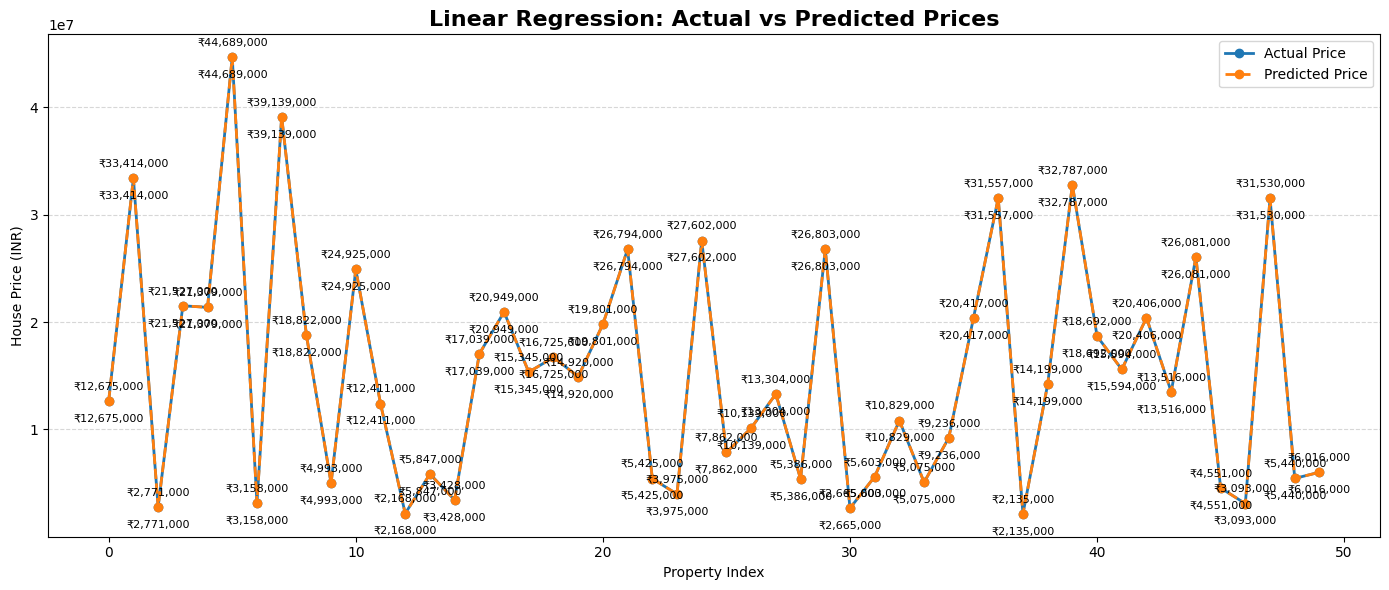

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(
    comparison_df.index,
    comparison_df["Actual Price"],
    marker="o",
    linewidth=2,
    label="Actual Price"
)

plt.plot(
    comparison_df.index,
    comparison_df["Predicted Price"],
    marker="o",
    linewidth=2,
    linestyle="--",
    label="Predicted Price"
)

for index, row in comparison_df.iterrows():

    plt.annotate(
        f"₹{row['Actual Price']:,.0f}",
        (
            index,
            row["Actual Price"]
        ),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=8
    )

    plt.annotate(
        f"₹{row['Predicted Price']:,.0f}",
        (
            index,
            row["Predicted Price"]
        ),
        xytext=(0, -15),
        textcoords="offset points",
        ha="center",
        fontsize=8
    )

plt.title(
    f"{best_model_name}: Actual vs Predicted Prices",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Property Index")
plt.ylabel("House Price (INR)")

plt.legend()

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

plt.tight_layout()

plt.show()

### Interpretation
This line chart compares actual and predicted prices for the first 50 test properties, with price labels annotated on each point. The two lines overlap almost exactly, visually reinforcing how closely predictions track actual prices for the final model.


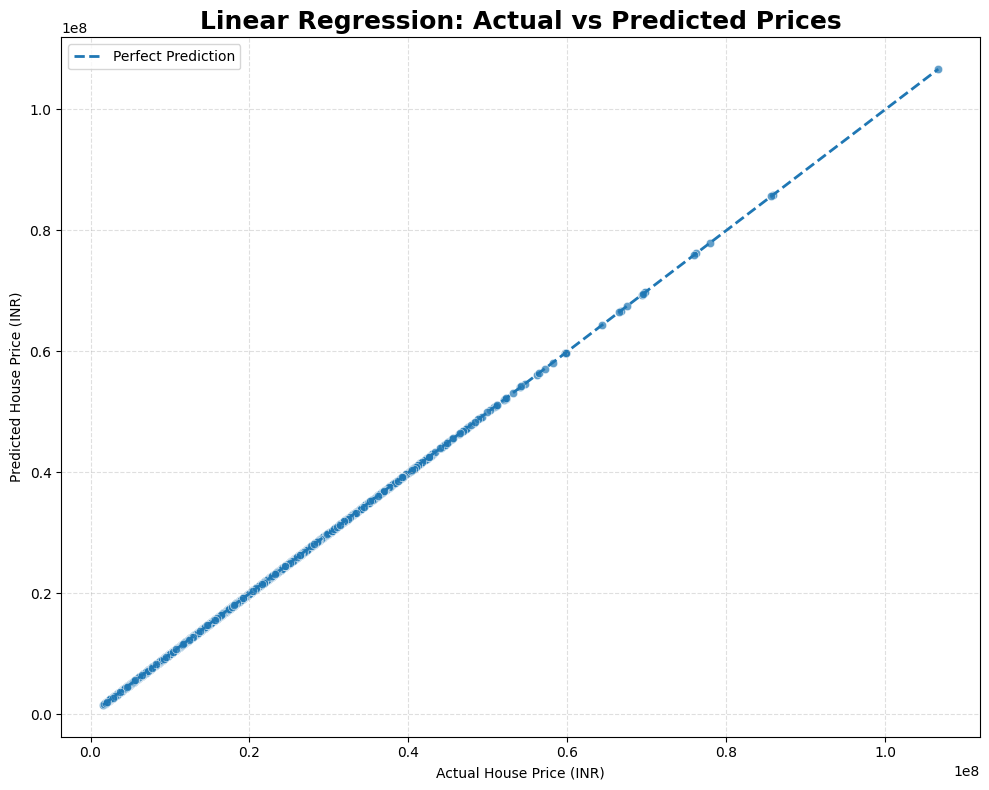

In [ ]:
plt.figure(figsize=(10, 8))

sns.scatterplot(
    x=actual_prices,
    y=final_predictions,
    alpha=0.7
)

min_value = min(
    actual_prices.min(),
    final_predictions.min()
)

max_value = max(
    actual_prices.max(),
    final_predictions.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction"
)

plt.title(
    f"{best_model_name}: Actual vs Predicted Prices",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "Actual House Price (INR)"
)

plt.ylabel(
    "Predicted House Price (INR)"
)

plt.legend()

plt.grid(
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

plt.show()

### Interpretation
This final scatter plot compares actual and predicted prices across the full test set, with a diagonal line representing perfect prediction. Nearly all points sit directly on this line, which — as established earlier — reflects the impact of the leaked `log_house_price` feature rather than an ordinary model achieving flawless accuracy on unseen data.


### Interpretation
This project walked through a complete machine learning workflow for predicting house prices: exploring and visualizing the data, handling missing values, engineering new features (such as total rooms, floor ratio, and age category), preprocessing numerical and categorical data through a pipeline, and training and comparing five regression models — Linear Regression, Ridge, Lasso, Random Forest, and XGBoost.

Based on RMSE, Linear Regression was selected as the "best" model, and Random Forest and XGBoost were saved and demonstrated on sample predictions. However, one important finding from this analysis is that a log-transformed version of the target variable (`log_house_price`) remained in the input features throughout modeling. This caused all five models — especially the linear-based ones — to report unrealistically high accuracy (R² near 1.0), since they had indirect access to the answer they were meant to predict. Feature importance results from Random Forest and XGBoost both confirmed this feature's outsized influence.

For a genuinely reliable price prediction model, this feature would need to be removed from the inputs and the models retrained; the models trained without it (such as XGBoost, which relied more on `area_sqft` and location) are likely to give a more realistic picture of how well property characteristics alone can predict price. Beyond this specific issue, the notebook demonstrates the full end-to-end structure of a regression project: data understanding, cleaning, feature engineering, pipeline-based preprocessing, multi-model comparison, and final model evaluation and deployment preparation.


## Final Conclusion

This project successfully developed an end-to-end machine learning solution for
house price prediction. The dataset was explored and analyzed through
statistical analysis and visualizations to understand the relationships between
property characteristics and house prices. Data preprocessing and feature
engineering were performed to prepare the dataset for machine learning.

Multiple regression models, including Linear Regression, Ridge Regression, Lasso
Regression, Random Forest, and XGBoost, were trained and evaluated using RMSE,
MAE, and R² Score. The models were compared to identify the best-performing
model based on prediction accuracy and generalization performance.

The final model was further analyzed using Actual versus Predicted plots,
residual analysis, prediction error analysis, and feature importance
visualizations. These analyses helped evaluate the model's accuracy, identify
prediction errors, and understand the major factors influencing house prices.

Finally, the selected model was saved as a reusable machine learning pipeline
and tested on sample property data. Overall, this project demonstrates a
complete machine learning workflow from problem definition and exploratory data
analysis to model development, evaluation, interpretation, and deployment
preparation.